# Transfer Learning using PyTorch

In [1]:
!nvidia-smi

Mon Mar 16 22:04:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   43C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## Load Important Libraries

In [2]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

## Load Data
=========

We will use torchvision and torch.utils.data packages for loading the
data.

The problem we\'re going to solve today is to train a model to classify
**ants** and **bees**. We have about 120 training images each for ants
and bees. There are 75 validation images for each class. Usually, this
is a very small dataset to generalize upon, if trained from scratch.
Since we are using transfer learning, we should be able to generalize
reasonably well.

This dataset is a very small subset of imagenet.


In [3]:
!rm -R /content/hymenoptera_data/train/.ipynb_checkpoints
!ls /content/hymenoptera_data/test/train -a   #to make sure that the deletion has occurred

!rm -R /content/hymenoptera_data/val/.ipynb_checkpoints
!ls /content/hymenoptera_data/val -a   #to make sure that the deletion has occurred

rm: cannot remove '/content/hymenoptera_data/train/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/hymenoptera_data/test/train': No such file or directory
rm: cannot remove '/content/hymenoptera_data/val/.ipynb_checkpoints': No such file or directory
ls: cannot access '/content/hymenoptera_data/val': No such file or directory


In [7]:
!wget https://download.pytorch.org/tutorial/hymenoptera_data.zip
!unzip hymenoptera_data.zip

--2026-03-16 22:08:48--  https://download.pytorch.org/tutorial/hymenoptera_data.zip
Resolving download.pytorch.org (download.pytorch.org)... 99.84.215.76, 99.84.215.59, 99.84.215.85, ...
Connecting to download.pytorch.org (download.pytorch.org)|99.84.215.76|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47286322 (45M) [application/zip]
Saving to: ‘hymenoptera_data.zip’

hymenoptera_data.zi 100%[===================>]  45.10M   220MB/s    in 0.2s    

2026-03-16 22:08:48 (220 MB/s) - ‘hymenoptera_data.zip’ saved [47286322/47286322]

Archive:  hymenoptera_data.zip
   creating: hymenoptera_data/
   creating: hymenoptera_data/train/
   creating: hymenoptera_data/train/ants/
  inflating: hymenoptera_data/train/ants/0013035.jpg  
  inflating: hymenoptera_data/train/ants/1030023514_aad5c608f9.jpg  
  inflating: hymenoptera_data/train/ants/1095476100_3906d8afde.jpg  
  inflating: hymenoptera_data/train/ants/1099452230_d1949d3250.jpg  
  inflating: hymenoptera_data/tra

In [8]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

data_dir = '/content/hymenoptera_data'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                                             shuffle=True, num_workers=4)
              for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


## Visualize a few images
======================

Let\'s visualize a few training images so as to understand the data
augmentations.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


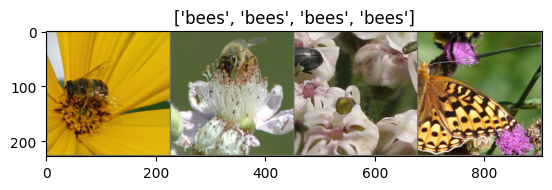

In [9]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

## Training the model
==================

Now, let\'s write a general function to train a model. Here, we will
illustrate:

-   Scheduling the learning rate
-   Saving the best model

In the following, parameter `scheduler` is an LR scheduler object from
`torch.optim.lr_scheduler`.


In [10]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Each epoch has a training and validation phase
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

## Visualizing the model predictions
=================================

Generic function to display predictions for a few images


In [11]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images//2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)

## Finetuning the ConvNet
======================

Load a pretrained model and reset final fully connected layer.


In [12]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
# Here the size of each output sample is set to 2.
# Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 199MB/s]


## Train and evaluate
==================

It should take around 15-25 min on CPU. On GPU though, it takes less
than a minute.


In [13]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6917 Acc: 0.6270
val Loss: 0.2648 Acc: 0.8758

Epoch 1/24
----------
train Loss: 0.5582 Acc: 0.7459
val Loss: 0.3441 Acc: 0.8693

Epoch 2/24
----------
train Loss: 0.5858 Acc: 0.7336
val Loss: 0.4013 Acc: 0.8235

Epoch 3/24
----------
train Loss: 0.4790 Acc: 0.8238
val Loss: 0.5173 Acc: 0.8366

Epoch 4/24
----------
train Loss: 0.3820 Acc: 0.8361
val Loss: 0.2103 Acc: 0.9281

Epoch 5/24
----------
train Loss: 0.3454 Acc: 0.8648
val Loss: 0.5216 Acc: 0.8105

Epoch 6/24
----------
train Loss: 0.4077 Acc: 0.8320
val Loss: 0.2944 Acc: 0.9020

Epoch 7/24
----------
train Loss: 0.4937 Acc: 0.8197
val Loss: 0.2360 Acc: 0.9020

Epoch 8/24
----------
train Loss: 0.3401 Acc: 0.8525
val Loss: 0.2498 Acc: 0.9020

Epoch 9/24
----------
train Loss: 0.3004 Acc: 0.8811
val Loss: 0.2141 Acc: 0.9346

Epoch 10/24
----------
train Loss: 0.2786 Acc: 0.8811
val Loss: 0.1928 Acc: 0.9281

Epoch 11/24
----------
train Loss: 0.3489 Acc: 0.8730
val Loss: 0.1829 Acc: 0.9346

Ep

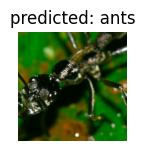

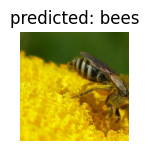

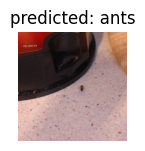

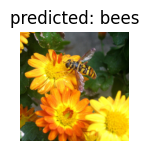

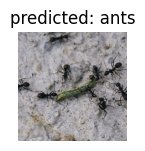

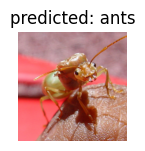

In [14]:
visualize_model(model_ft)

## ConvNet as fixed feature extractor
==================================

Here, we need to freeze all the network except the final layer. We need
to set `requires_grad = False` to freeze the parameters so that the
gradients are not computed in `backward()`.

You can read more about this in the documentation
[here](https://pytorch.org/docs/notes/autograd.html#excluding-subgraphs-from-backward).


In [15]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Parameters of newly constructed modules have requires_grad=True by default
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Observe that only parameters of final layer are being optimized as
# opposed to before.
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Decay LR by a factor of 0.1 every 7 epochs
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

## Train and evaluate
==================

On CPU this will take about half the time compared to previous scenario.
This is expected as gradients don\'t need to be computed for most of the
network. However, forward does need to be computed.


In [16]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)

Epoch 0/24
----------
train Loss: 0.6776 Acc: 0.6352
val Loss: 0.2385 Acc: 0.9346

Epoch 1/24
----------
train Loss: 0.5840 Acc: 0.7090
val Loss: 0.3669 Acc: 0.8431

Epoch 2/24
----------
train Loss: 0.5738 Acc: 0.7541
val Loss: 0.2567 Acc: 0.9020

Epoch 3/24
----------
train Loss: 0.5736 Acc: 0.7869
val Loss: 0.2820 Acc: 0.8889

Epoch 4/24
----------
train Loss: 0.8967 Acc: 0.6885
val Loss: 0.1872 Acc: 0.9477

Epoch 5/24
----------
train Loss: 0.4248 Acc: 0.8361
val Loss: 0.2126 Acc: 0.9477

Epoch 6/24
----------
train Loss: 0.3355 Acc: 0.8730
val Loss: 0.3737 Acc: 0.8758

Epoch 7/24
----------
train Loss: 0.2907 Acc: 0.8566
val Loss: 0.2104 Acc: 0.9412

Epoch 8/24
----------
train Loss: 0.3791 Acc: 0.8320
val Loss: 0.2265 Acc: 0.9346

Epoch 9/24
----------
train Loss: 0.3447 Acc: 0.8484
val Loss: 0.2248 Acc: 0.9412

Epoch 10/24
----------
train Loss: 0.4523 Acc: 0.8238
val Loss: 0.2082 Acc: 0.9412

Epoch 11/24
----------
train Loss: 0.3260 Acc: 0.8811
val Loss: 0.1905 Acc: 0.9281

Ep

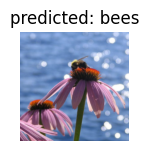

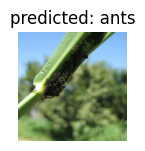

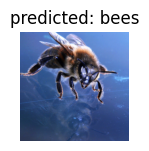

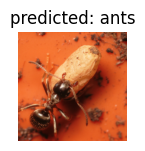

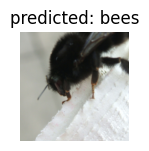

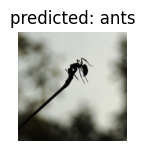

In [17]:
visualize_model(model_conv)

plt.ioff()
plt.show()

## Inference on custom images
==========================

Use the trained model to make predictions on custom images and visualize
the predicted class labels along with the images.


In [18]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

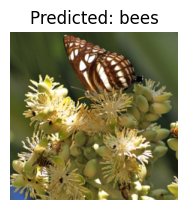

In [19]:
visualize_model_predictions(
    model_conv,
    img_path='/content/hymenoptera_data/val/bees/72100438_73de9f17af.jpg'
)

plt.ioff()
plt.show()

## Further Learning
================

If you would like to learn more about the applications of transfer
learning, checkout the
* [Quantized Transfer Learning for Computer Vision
Tutorial](https://pytorch.org/tutorials/intermediate/quantized_transfer_learning_tutorial.html).


# Supplementary Activity (and Assessment Task 4.1)

In a new notebook, perform the following:
1. Choose a pretrained model.
2. Finetune on your dataset from the previous activity.
3. Evaluate the performance of the previous model to this finetuned model.

4. Utilize the pretrained ConvNet model as fixed feature extractor.
5. Evaluate the performance of the previous model to this finetuned model.

6.  Discuss the following:
  * How did finetuning affect your performance?
  * Which of the different situations for rule of thumb were applicable to you?

## Libraries

In [27]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Import Data

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

from google.colab import drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa4.1/SalmonScan A Novel Image Dataset for Machine Learning and Deep Learning Analysis in Fish Disease Detection in Aquaculture/SalmonScan/Augmented'

Using cuda device
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Explore dataset

In [29]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),      # ResNet50 expects 224x224
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Load twice — train gets augmentation, val/test does not
train_full = datasets.ImageFolder(root=dataset_path, transform=train_transform)
test_full  = datasets.ImageFolder(root=dataset_path, transform=val_transform)

class_names = train_full.classes
num_classes = len(class_names)
print(f"Classes    : {class_names}")
print(f"Total imgs : {len(train_full)}")

Classes    : ['FreshFish', 'InfectedFish']
Total imgs : 1208


## split data, create dataloaders

In [30]:
from torch.utils.data import Subset

n       = len(train_full)
n_train = int(0.8 * n)
n_val   = int(0.1 * n)
n_test  = n - n_train - n_val

# Fixed seed for reproducibility
generator = torch.Generator().manual_seed(42)
indices   = torch.randperm(n, generator=generator).tolist()

train_indices = indices[:n_train]
val_indices   = indices[n_train:n_train + n_val]
test_indices  = indices[n_train + n_val:]

train_ds = Subset(train_full, train_indices)
val_ds   = Subset(test_full,  val_indices)
test_ds  = Subset(test_full,  test_indices)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

Train: 966 | Val: 120 | Test: 122


## Shared Train/Test/Evaluate Functions

In [31]:
def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 10 == 0:
            loss, current = loss.item(), batch * 32 + len(X)
            print(f"  loss: {loss:>7f}  [{current:>4d}/{size:>4d}]")

def test_loop(dataloader, model, loss_fn):
    model.eval()
    size        = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct   += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct   /= size
    print(f"  Accuracy: {(100*correct):>0.1f}%  |  Avg loss: {test_loss:>8f}")
    return round(100 * correct, 2), round(test_loss, 6)

def evaluate(model, test_loader, label="Model"):
    all_preds, all_labels = [], []
    model.eval()
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.to(device), y.to(device)
            all_preds.extend(model(X).argmax(1).cpu().numpy())
            all_labels.extend(y.cpu().numpy())

    print(f"\n{'='*50}")
    print(f" Evaluation: {label}")
    print(f"{'='*50}")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm   = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"Confusion Matrix — {label}")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels

## using model from HOA4.1

FishDiseaseNet(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=256, out_features=2, bias=True)
  )
)

── Custom CNN Training ──

Epoch 1
-------------------------------
  loss: 0.690710  [  32/ 966]
  loss: 0.367325  [ 352/ 966]
  loss: 0.716903  [ 672/ 966]
  loss: 0.71319

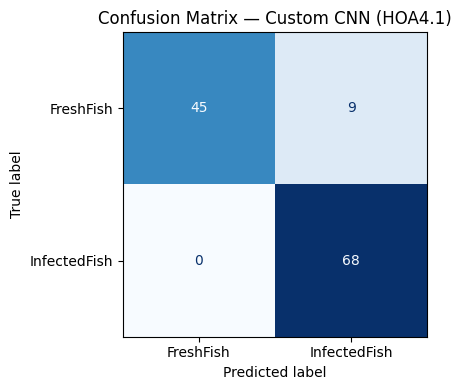

In [45]:
num_classes = len(class_names)

class FishDiseaseNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),  #modified: 224x224 input → 28x28 after 3 MaxPool
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_cnn = FishDiseaseNet().to(device)
print(model_cnn)

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_cnn.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

epochs = 10
cnn_train_acc,  cnn_val_acc  = [], []
cnn_train_loss, cnn_val_loss = [], []

print("\n── Custom CNN Training ──")
for t in range(epochs):
    print(f"\nEpoch {t+1}\n-------------------------------")
    train_loop(train_loader, model_cnn, loss_fn, optimizer)
    print("Train:"); t_acc, t_loss = test_loop(train_loader, model_cnn, loss_fn)
    print("Val:");   v_acc, v_loss = test_loop(val_loader,   model_cnn, loss_fn)
    scheduler.step()

    cnn_train_acc.append(t_acc);  cnn_val_acc.append(v_acc)
    cnn_train_loss.append(t_loss); cnn_val_loss.append(v_loss)

print("\nDone!")

# ── Evaluate on test set ──────────────────────────────────────────────
cnn_preds, cnn_labels = evaluate(model_cnn, test_loader, label="Custom CNN (HOA4.1)")

## using ResNet50 as pretrained model


── Finetuned ResNet50 Training ──

Epoch 1
-------------------------------
  loss: 0.695745  [  32/ 966]
  loss: 0.342116  [ 352/ 966]
  loss: 0.365634  [ 672/ 966]
  loss: 0.296150  [ 966/ 966]
Train:
  Accuracy: 94.9%  |  Avg loss: 0.296029
Val:
  Accuracy: 99.2%  |  Avg loss: 0.246012

Epoch 2
-------------------------------
  loss: 0.247699  [  32/ 966]
  loss: 0.546824  [ 352/ 966]
  loss: 0.281237  [ 672/ 966]
  loss: 0.258132  [ 966/ 966]
Train:
  Accuracy: 99.1%  |  Avg loss: 0.228668
Val:
  Accuracy: 99.2%  |  Avg loss: 0.231323

Epoch 3
-------------------------------
  loss: 0.218738  [  32/ 966]
  loss: 0.220065  [ 352/ 966]
  loss: 0.230045  [ 672/ 966]
  loss: 0.598849  [ 966/ 966]
Train:
  Accuracy: 99.6%  |  Avg loss: 0.215267
Val:
  Accuracy: 99.2%  |  Avg loss: 0.239962
  EarlyStopping: no improvement (1/4)

Epoch 4
-------------------------------
  loss: 0.240239  [  32/ 966]
  loss: 0.218786  [ 352/ 966]
  loss: 0.220115  [ 672/ 966]
  loss: 0.227753  [ 966/ 966]
T

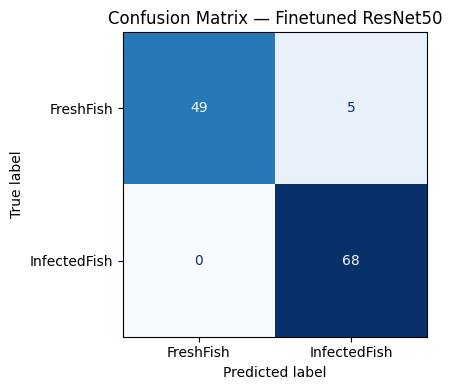

In [42]:
#Finetuned ResNet50 (with overfitting prevention)
model_ft = models.resnet50(weights='IMAGENET1K_V1')

# Partial unfreezing — only unfreeze the last 2 layer groups
# Freezing early layers preserves general features (edges, textures)
# Only fine-tune deeper layers that learn task-specific features
for param in model_ft.parameters():
    param.requires_grad = False

# Unfreeze only layer3, layer4, and fc
for param in model_ft.layer3.parameters():
    param.requires_grad = True
for param in model_ft.layer4.parameters():
    param.requires_grad = True

# Replace final layer with stronger regularization
model_ft.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model_ft.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(256, num_classes)
)
model_ft = model_ft.to(device)

loss_fn = nn.CrossEntropyLoss(label_smoothing=0.1)# label smoothing reduces overconfidence

# Different LRs per layer group — lower for pretrained, higher for new layers
optimizer = torch.optim.Adam([
    {'params': model_ft.layer3.parameters(), 'lr': 1e-5},# very low — mostly frozen knowledge
    {'params': model_ft.layer4.parameters(), 'lr': 1e-4},# low — fine-tune carefully
    {'params': model_ft.fc.parameters(),     'lr': 1e-3},# normal — new layer trains freely
], weight_decay=1e-4)# L2 regularization

# ReduceLROnPlateau reduces LR when val loss stops improving
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=2, factor=0.5,
)

#Early stopping helper
class EarlyStopping:
    def __init__(self, patience=4, min_delta=0.001):
        self.patience   = patience
        self.min_delta  = min_delta
        self.counter    = 0
        self.best_loss  = float('inf')
        self.best_weights = None

    def step(self, val_loss, model):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
            self.counter      = 0
        else:
            self.counter += 1
            print(f"  EarlyStopping: no improvement ({self.counter}/{self.patience})")
            if self.counter >= self.patience:
                print("  Stopping early — restoring best weights")
                model.load_state_dict(self.best_weights)
                return True
        return False

early_stopping = EarlyStopping(patience=4)

epochs = 10
ft_train_acc,  ft_val_acc  = [], []
ft_train_loss, ft_val_loss = [], []

print("\n── Finetuned ResNet50 Training ──")
for t in range(epochs):
    print(f"\nEpoch {t+1}\n-------------------------------")
    train_loop(train_loader, model_ft, loss_fn, optimizer)
    print("Train:"); t_acc, t_loss = test_loop(train_loader, model_ft, loss_fn)
    print("Val:");   v_acc, v_loss = test_loop(val_loader,   model_ft, loss_fn)

    scheduler.step(v_loss)                             # ReduceLROnPlateau needs val loss

    ft_train_acc.append(t_acc);  ft_val_acc.append(v_acc)
    ft_train_loss.append(t_loss); ft_val_loss.append(v_loss)

    if early_stopping.step(v_loss, model_ft):# stop if val loss stops improving
        epochs = t + 1# update for accurate chart x-axis
        break

print("\nDone!")

# Evaluate on test set
ft_preds, ft_labels = evaluate(model_ft, test_loader, label="Finetuned ResNet50")

## using pretrained ConvNet model from procedure

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

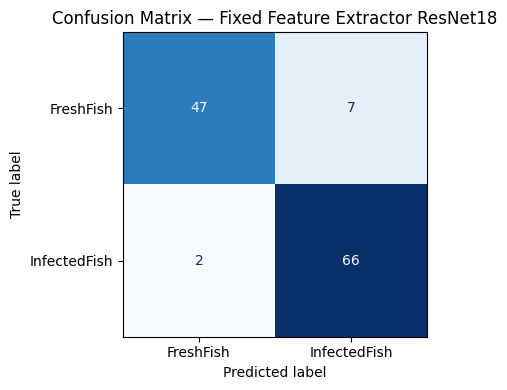

In [43]:
# ── Pretrained ConvNet as Fixed Feature Extractor ─────────────────────
# Mirrors the procedure's approach — backbone frozen, only fc trains
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# Freeze ALL backbone layers
for param in model_conv.parameters():
    param.requires_grad = False

# Only the final layer is trainable (requires_grad=True by default)
model_conv.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model_conv.fc.in_features, num_classes)
)
model_conv = model_conv.to(device)
print(model_conv)

loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_conv.fc.parameters(), lr=1e-3)  # only fc trains
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3, gamma=0.5)

epochs = 10
conv_train_acc,  conv_val_acc  = [], []
conv_train_loss, conv_val_loss = [], []

print("Fixed Feature Extractor ResNet18 Training")
for t in range(epochs):
    print(f"\nEpoch {t+1}\n-------------------------------")
    train_loop(train_loader, model_conv, loss_fn, optimizer)
    print("Train:"); t_acc, t_loss = test_loop(train_loader, model_conv, loss_fn)
    print("Val:");   v_acc, v_loss = test_loop(val_loader,   model_conv, loss_fn)
    scheduler.step()

    conv_train_acc.append(t_acc);  conv_val_acc.append(v_acc)
    conv_train_loss.append(t_loss); conv_val_loss.append(v_loss)

print("\nDone!")

# Evaluate on test set
conv_preds, conv_labels = evaluate(model_conv, test_loader, label="Fixed Feature Extractor ResNet18")

## Evaluation and Comparisons

Final Test Accuracy Summary
  1. Custom CNN (HOA4.1)              : 92.62%
  2. Finetuned ResNet50               : 95.90%
  3. Fixed Feature Extractor ResNet50 : 92.62%

  Finetuned vs CNN improvement        : +3.28%
  Fixed Extractor vs CNN improvement  : +0.00%
  Finetuned vs Fixed Extractor        : +3.28%


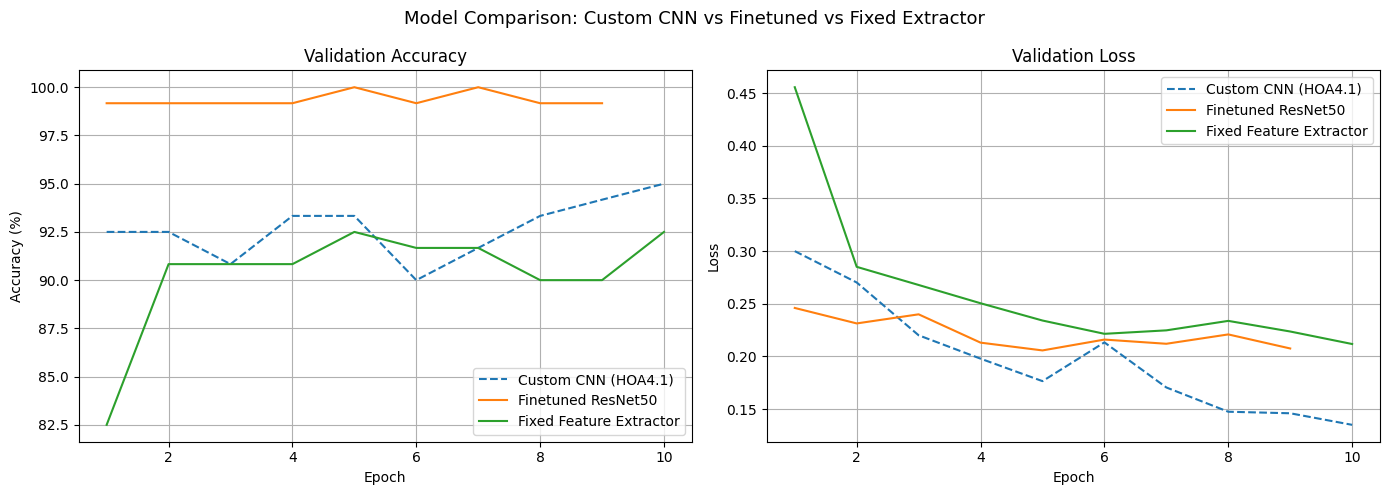

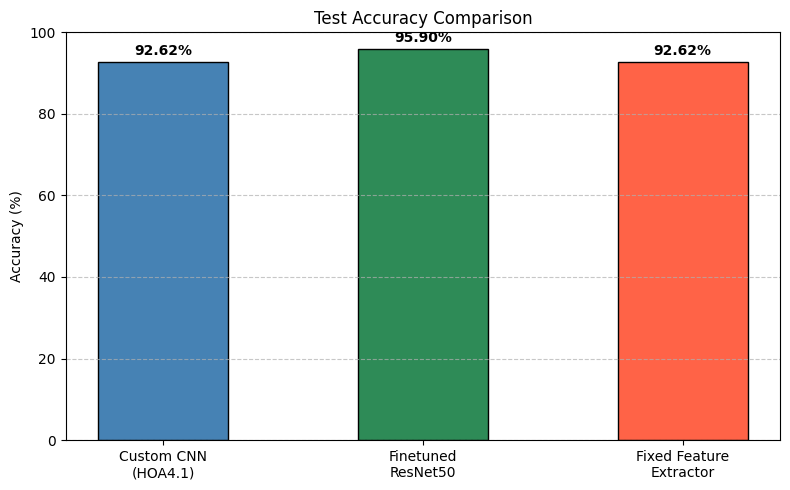

All models saved to Google Drive


In [47]:
from sklearn.metrics import accuracy_score

# Final test accuracy summary
cnn_acc  = accuracy_score(cnn_labels,  cnn_preds)  * 100
ft_acc   = accuracy_score(ft_labels,   ft_preds)   * 100
conv_acc = accuracy_score(conv_labels, conv_preds) * 100

print("Final Test Accuracy Summary")
print(f"  1. Custom CNN (HOA4.1)              : {cnn_acc:.2f}%")
print(f"  2. Finetuned ResNet50               : {ft_acc:.2f}%")
print(f"  3. Fixed Feature Extractor ResNet50 : {conv_acc:.2f}%")
print(f"\n  Finetuned vs CNN improvement        : +{ft_acc  - cnn_acc:.2f}%")
print(f"  Fixed Extractor vs CNN improvement  : +{conv_acc - cnn_acc:.2f}%")
print(f"  Finetuned vs Fixed Extractor        : +{ft_acc  - conv_acc:.2f}%")

#2. Validation curves — each model uses its own epoch range
# (ft may have stopped early so its history may be shorter)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Model Comparison: Custom CNN vs Finetuned vs Fixed Extractor", fontsize=13)

cnn_epochs  = range(1, len(cnn_val_acc)  + 1)   # ← each model tracks its own length
ft_epochs   = range(1, len(ft_val_acc)   + 1)
conv_epochs = range(1, len(conv_val_acc) + 1)

# Validation accuracy
axes[0].plot(cnn_epochs,  cnn_val_acc,  label="Custom CNN (HOA4.1)", linestyle='--')
axes[0].plot(ft_epochs,   ft_val_acc,   label="Finetuned ResNet50")
axes[0].plot(conv_epochs, conv_val_acc, label="Fixed Feature Extractor")
axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy (%)")
axes[0].legend()
axes[0].grid(True)

# Validation loss
axes[1].plot(cnn_epochs,  cnn_val_loss,  label="Custom CNN (HOA4.1)", linestyle='--')
axes[1].plot(ft_epochs,   ft_val_loss,   label="Finetuned ResNet50")
axes[1].plot(conv_epochs, conv_val_loss, label="Fixed Feature Extractor")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

#3. Bar chart comparison
fig, ax = plt.subplots(figsize=(8, 5))
model_names = ["Custom CNN\n(HOA4.1)", "Finetuned\nResNet50", "Fixed Feature\nExtractor"]
accuracies  = [cnn_acc, ft_acc, conv_acc]
colors      = ['steelblue', 'seagreen', 'tomato']

bars = ax.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.5)
ax.set_title("Test Accuracy Comparison")
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 1,
            f"{acc:.2f}%",
            ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#4. Save all models to Drive
base_path = '/content/drive/MyDrive/SCHOOLFILES/CPE32/CPE313/hoa4.2/'
torch.save(model_cnn.state_dict(),  base_path + 'hoa4_1_custom_cnn.pth')
torch.save(model_ft.state_dict(),   base_path + 'resnet50_finetuned.pth')
torch.save(model_conv.state_dict(), base_path + 'resnet50_fixed_extractor.pth')
print("All models saved to Google Drive")

* How did finetuning affect your performance?
<br>***Finetuning helped achieve a better performance in terms of accuracy and speed. Both the pretrained models using a finetuned ResNet50 and a pretrained fixed feature extractor ResNet18 surpassed the model I used in the past activity in terms of accuracy (95.9% from ResNet50) or speed (Fixed Feature Extractor trained faster)***

* Which of the different situations for rule of thumb were applicable to you?
<br>***finetuning the model and implementing measures to prevent the model from overfitting quite helped me in the task. I prevented the pretrained from overfitting on the given dataset by introducing early stopping if the performance didn't improve any further.***

# Conclusion

In this activity, I was able to learn how transfer learning is utilized in machine learning and deep learning tasks, and was able to realize how it helps in making model training a much easier and faster process. I was also able to learn about the drawbacks and possible areas to look out for when using pretrained models, such as the risk of overfitting.